# Geodesic Shooting: the Initial Value Problem

Most demos here solve the boundary-value problem (find the path between A and B). This one solves the initial-value problem: fire a particle from A with a chosen velocity and integrate the geodesic equation forward. This is the Finslerian exponential map, and it makes curvature visible by showing whether nearby trajectories converge or diverge. Rotate the 3-D scenes to follow the fans.

**Metric-first design.** A HAM `FinslerMetric` is specified by a single scalar field, the Finsler cost
$F(x, v)$, which defines the path energy
$$\mathcal{E}[\gamma] = \int \tfrac{1}{2}\, F^2(x, \dot{x})\, dt.$$
The geodesic spray, fundamental tensor, curvature, and Berwald parallel transport are then obtained by
automatic differentiation of $F$ with `jax.grad` / `jax.hessian`, rather than by hand-deriving
Christoffel symbols. The notebooks in this suite share a small plotting style (`ham.vis.style`) so the
figures stay consistent and readable.

## 1. Setup

The IVP is governed by the geodesic spray ODE (`spec/MATH_SPEC.md` § 2.1):
$$\dot{x} = v, \qquad \dot{v} = -2\,G^i(x, v) = \texttt{metric.geod\_acceleration}(x, v).$$
`geod_acceleration` is derived from the Hessian of the energy, not hand-coded. Below we write a short
integrator that calls it directly, then use the library's projected-RK4 `ExponentialMap` for the
experiments.

In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.io as pio
from plotly.colors import sample_colorscale

from ham.geometry import Euclidean, Sphere, Hyperboloid
from ham.solvers import ExponentialMap
from ham.vis.style import use_ham_style, PALETTE, plotly_layout, plotly_sphere, plotly_surface

pio.renderers.default = "plotly_mimetype"
use_ham_style()
jax.config.update("jax_enable_x64", False)

## 2. A short geodesic integrator

The spray is an ODE, so any integrator works. Here is a projected semi-implicit Euler stepper that calls
`metric.geod_acceleration` and re-projects onto the manifold each step — enough to show that the physics
engine needs very little code.

In [2]:
def integrate_geodesic(metric, x0, v0, t_max=1.0, n=400):
    dt = t_max / n
    mani = metric.manifold

    def step(carry, _):
        x, v = carry
        v = v + dt * metric.geod_acceleration(x, v)
        x = mani.retract(x, dt * v)
        v = mani.to_tangent(x, v)
        return (x, v), x

    (_, _), xs = jax.lax.scan(step, (x0, v0), None, length=n)
    return jnp.concatenate([x0[None], xs], axis=0)


sphere = Sphere(radius=1.0)
metric = Euclidean(sphere)
x0 = jnp.array([1.0, 0.0, 0.0])
path = integrate_geodesic(metric, x0, sphere.to_tangent(x0, jnp.array([0.0, 1.0, 0.3])), t_max=2.0)
print("on-sphere error along path:", float(jnp.max(jnp.abs(jnp.linalg.norm(path, axis=1) - 1.0))))

on-sphere error along path: 5.960464477539063e-08


## 3. The cannon: a fan of perturbed shots

From a single base point we fire a fan of geodesics whose initial velocities are rotated by small angles
around a central aim, all at unit speed. The fan's evolution is set by the sign of the curvature. We use
`ExponentialMap` (projected RK4) and batch the fan with `vmap`.

In [3]:
expmap = ExponentialMap(max_steps=400)


def unit_tangent(mani, x, v):
    v = mani.to_tangent(x, v)
    return v / (mani.tangent_norm(x, v) + 1e-9)


def fan(metric, x0, aim, ortho, spread_deg, n_rays, t_max):
    mani = metric.manifold
    aim = unit_tangent(mani, x0, aim)
    ortho = unit_tangent(mani, x0, ortho)
    angles = jnp.deg2rad(jnp.linspace(-spread_deg, spread_deg, n_rays))

    def one(theta):
        v = unit_tangent(mani, x0, jnp.cos(theta) * aim + jnp.sin(theta) * ortho)
        xs, _ = expmap.trace(metric, x0, v, t_max=t_max)
        return xs

    return np.array(jax.vmap(one)(angles)), np.array(angles)


def add_fan(fig, rays, scale="Blues"):
    cols = sample_colorscale(scale, np.linspace(0.35, 0.9, rays.shape[0]))
    for i in range(rays.shape[0]):
        fig.add_trace(go.Scatter3d(x=rays[i, :, 0], y=rays[i, :, 1], z=rays[i, :, 2],
                                   mode="lines", line=dict(color=cols[i], width=4),
                                   showlegend=False, hoverinfo="skip"))

## 4. Positive curvature ($S^2$): the fan refocuses

On the sphere, all geodesics through a point reconverge at its antipode — a conjugate point at arclength
$\pi$. A diverging fan narrows back to a single spot. This focusing is the signature of positive
curvature.

In [4]:
m_sphere = Euclidean(sphere)
x0 = jnp.array([1.0, 0.0, 0.0])
rays_s, _ = fan(m_sphere, x0, jnp.array([0.0, 1.0, 0.0]), jnp.array([0.0, 0.0, 1.0]),
                spread_deg=35.0, n_rays=15, t_max=float(np.pi))

fig = go.Figure()
fig.add_trace(plotly_sphere(1.0))
add_fan(fig, rays_s)
fig.add_trace(go.Scatter3d(x=[x0[0]], y=[x0[1]], z=[x0[2]], mode="markers",
                           marker=dict(size=5, color=PALETTE["ink"]), name="launch point"))
fig.add_trace(go.Scatter3d(x=[-x0[0]], y=[-x0[1]], z=[-x0[2]], mode="markers",
                           marker=dict(size=6, color=PALETTE["accent"]), name="conjugate point"))
plotly_layout(fig, "Sphere: the fan refocuses at the antipode")
fig.show()

## 5. Negative curvature ($\mathbb{H}^2$): the fan diverges

On the upper sheet of the hyperboloid (Minkowski space, $\langle x,x\rangle_{\mathcal L}=-1$), nearby
geodesics separate like $\sinh(\text{distance})$ — exponentially. This is the mechanism behind
sensitivity to initial conditions and why hyperbolic spaces spread hierarchical data. We plot in the
ambient coordinates $(x_1, x_2, x_0)$, with $x_0$ the Minkowski "height".

In [5]:
hyp = Hyperboloid(intrinsic_dim=2)
m_hyp = Euclidean(hyp)
h0 = hyp.project(jnp.array([1.0, 0.0, 0.0]))
rays_h, _ = fan(m_hyp, h0, jnp.array([0.0, 1.0, 0.0]), jnp.array([0.0, 0.0, 1.0]),
                spread_deg=35.0, n_rays=15, t_max=2.2)

a, b = np.mgrid[-4:4:50j, -4:4:50j]
fig = go.Figure()
fig.add_trace(plotly_surface(a, b, np.sqrt(1 + a**2 + b**2), opacity=0.3))
cols = sample_colorscale("Oranges", np.linspace(0.35, 0.9, rays_h.shape[0]))
for i in range(rays_h.shape[0]):
    fig.add_trace(go.Scatter3d(x=rays_h[i, :, 1], y=rays_h[i, :, 2], z=rays_h[i, :, 0],
                               mode="lines", line=dict(color=cols[i], width=4),
                               showlegend=False, hoverinfo="skip"))
fig.add_trace(go.Scatter3d(x=[h0[1]], y=[h0[2]], z=[h0[0]], mode="markers",
                           marker=dict(size=5, color=PALETTE["ink"]), name="launch point"))
plotly_layout(fig, "Hyperboloid: the same fan spreads without bound", eye=(1.4, 1.4, 1.1))
fig.show()

## 6. The curvature signature: separation vs. arclength

Tracking the intrinsic distance between two geodesics launched $1^\circ$ apart quantifies the pictures
above. Jacobi's equation gives $\ddot J = -K\,J$:

* $K>0$ (sphere): $J(t)\propto \sin t$ — grows, then returns to zero.
* $K<0$ (hyperboloid): $J(t)\propto \sinh t$ — grows without bound.

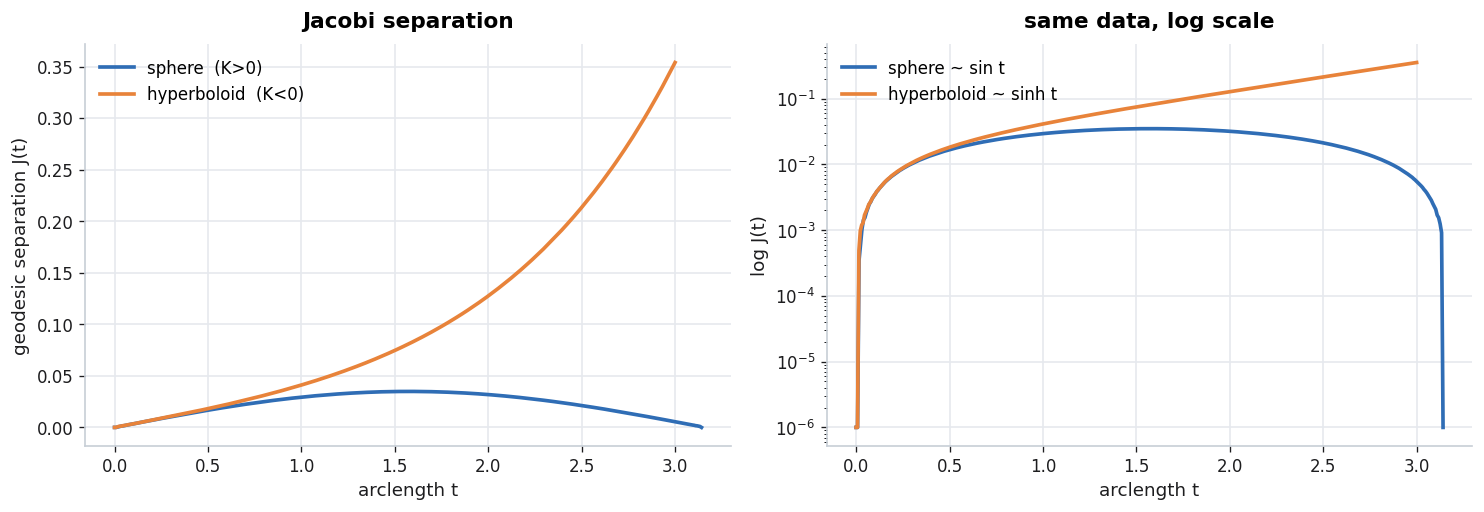

sphere    : J peaks at 0.035, returns to 0.000
hyperbolic: J grows to 0.354 and keeps going


In [6]:
def sphere_dist(p, q):
    return np.arccos(np.clip(np.sum(p * q, -1), -1, 1))

def hyp_dist(p, q):
    mink = -p[..., 0] * q[..., 0] + np.sum(p[..., 1:] * q[..., 1:], -1)
    return np.arccosh(np.clip(-mink, 1, None))

def separation(metric, x0, aim, ortho, t_max, distfn):
    rays, _ = fan(metric, x0, aim, ortho, spread_deg=1.0, n_rays=2, t_max=t_max)
    ts = np.linspace(0, t_max, rays.shape[1])
    return ts, distfn(rays[0], rays[1])

ts_s, sep_s = separation(m_sphere, x0, jnp.array([0., 1., 0.]), jnp.array([0., 0., 1.]),
                         float(np.pi), sphere_dist)
ts_h, sep_h = separation(m_hyp, h0, jnp.array([0., 1., 0.]), jnp.array([0., 0., 1.]),
                         3.0, hyp_dist)

fig, ax = plt.subplots(1, 2, figsize=(12.5, 4.4))
ax[0].plot(ts_s, sep_s, color=PALETTE["primary"], label="sphere  (K>0)")
ax[0].plot(ts_h, sep_h, color=PALETTE["accent"], label="hyperboloid  (K<0)")
ax[0].set(xlabel="arclength t", ylabel="geodesic separation J(t)", title="Jacobi separation")
ax[0].legend()
ax[1].semilogy(ts_s, sep_s + 1e-6, color=PALETTE["primary"], label="sphere ~ sin t")
ax[1].semilogy(ts_h, sep_h + 1e-6, color=PALETTE["accent"], label="hyperboloid ~ sinh t")
ax[1].set(xlabel="arclength t", ylabel="log J(t)", title="same data, log scale")
ax[1].legend()
plt.tight_layout(); plt.show()

print(f"sphere    : J peaks at {sep_s.max():.3f}, returns to {sep_s[-1]:.3f}")
print(f"hyperbolic: J grows to {sep_h[-1]:.3f} and keeps going")

## 7. Notes

* The IVP (`ExponentialMap`, the spray ODE) and the BVP (`AVBDSolver`) are two views of the same
  geodesic equation — shooting versus relaxation.
* `metric.geod_acceleration` is all that a custom integrator needs; the curvature it encodes is
  auto-differentiated from the single scalar $F$.
* The same `fan(...)` call on two manifolds makes the Jacobi equation visible: positive curvature
  refocuses initial-condition errors, negative curvature amplifies them.